In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

In [53]:

# =========================================
# Settings
# =========================================
fname_in1 = "../Python/out_case_nn_120s.txt"
fname_in2 = "../Python/out_case_nn_240s.txt"
#fname_in2 = "../Python/out_case_nn_360s.txt"
#fname_in2 = "../Python/out_case_nn_480s.txt"
#fname_in2 = "../Python/out_case_nn_600s.txt"
#fname_in2 = "../Python/out_case_nn_1200s.txt"
#fname_in2 = "../Python/out_case_nn_120s.txt"
out_form = "X11"   # or "png"

clevs_t  = np.arange(10, 16, 0.2)
clevs_s  = np.arange(32, 36.2, 0.2)
clevs_uv = np.arange(-0.3, 0.4, 0.05)
ylim = (70, 0)

# =========================================
# Reader utilities
# =========================================
def _read_nonempty_line(f):
    while True:
        line = f.readline()
        if line == "":
            raise EOFError("Unexpected end of file.")
        line = line.strip()
        if line:
            return line

def _read_floats_line(f, expected_len=None, name="array"):
    vals = np.fromstring(_read_nonempty_line(f), sep=" ", dtype=float)
    if expected_len is not None and len(vals) != expected_len:
        raise ValueError(f"{name}: expected length {expected_len}, got {len(vals)}")
    return vals

# =========================================
# Main reader
# =========================================
def read_profile_file(fname):
    with open(fname, "r") as f:
        # ntime
        ntime = int(_read_nonempty_line(f).split()[0])

        # z
        z = _read_floats_line(f, name="z")
        nz = len(z)

        times = np.empty(ntime, dtype="datetime64[s]")
        temp  = np.empty((ntime, nz))
        salt  = np.empty((ntime, nz))
        u     = np.empty((ntime, nz))
        v     = np.empty((ntime, nz))

        for it in range(ntime):
            y, mo, d, hh, mm, ss = map(int, _read_nonempty_line(f).split()[:6])
            times[it] = np.datetime64(datetime(y, mo, d, hh, mm, ss))

            temp[it, :] = _read_floats_line(f, nz, "temp")
            salt[it, :] = _read_floats_line(f, nz, "salt")
            u[it, :]    = _read_floats_line(f, nz, "u")
            v[it, :]    = _read_floats_line(f, nz, "v")

    return times, z, temp, salt, u, v

In [54]:

# =========================================
# Read two files
# =========================================
times_1, z_1, temp_1, salt_1, u_1, v_1 = read_profile_file(fname_in1)
times_2, z_2, temp_2, salt_2, u_2, v_2 = read_profile_file(fname_in2)

# --- consistency check ---
if not np.array_equal(z_1, z_2):
    raise ValueError("z grids differ between files")
if not np.array_equal(times_1, times_2):
    raise ValueError("time axis differs between files")

times = times_1
z     = z_1


['1900-01-02T00:00:00' '1900-01-03T00:00:00' '1900-01-04T00:00:00'
 '1900-01-05T00:00:00' '1900-01-06T00:00:00' '1900-01-07T00:00:00'
 '1900-01-08T00:00:00' '1900-01-09T00:00:00' '1900-01-10T00:00:00'
 '1900-01-11T00:00:00' '1900-01-12T00:00:00' '1900-01-13T00:00:00'
 '1900-01-14T00:00:00' '1900-01-15T00:00:00' '1900-01-16T00:00:00'
 '1900-01-17T00:00:00' '1900-01-18T00:00:00' '1900-01-19T00:00:00'
 '1900-01-20T00:00:00' '1900-01-21T00:00:00']


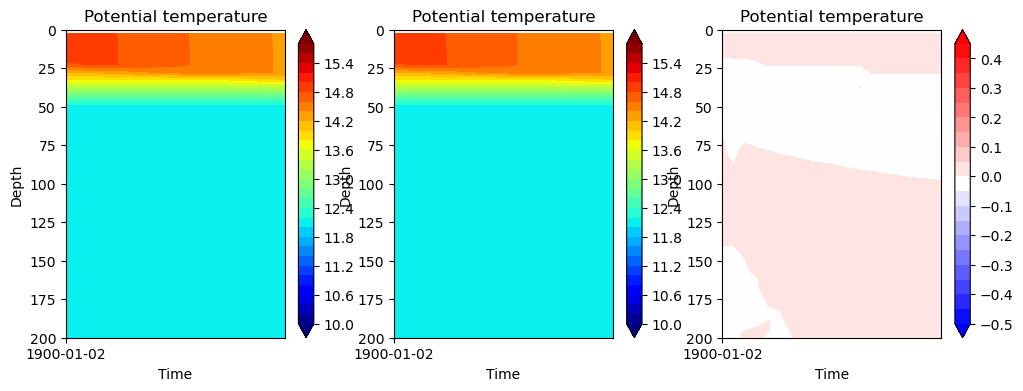

In [55]:
times=np.asarray(times)
z=np.asarray(z)
x,y=np.meshgrid(times,z)
clevs_t=np.arange(10,16,0.2)
clevs_t_diff=np.arange(-0.5,0.5,0.05)
clevs_s=np.arange(32,36.2,0.2)
clevs_uv=np.arange(-0.3,0.4,0.05)
xticks=times[0::5]
xticks=times[0::30]
xticks=times[0::60]
print(times)
ylim=[70,0]
ylim=[200,0]
fig = plt.figure(figsize=(12, 4))
plt.subplot(1,3,1)
plt.contourf(x,y,np.transpose(temp_1),cmap="jet",extend="both",levels=clevs_t)
plt.xticks(xticks)
plt.ylim(ylim)
plt.title("Potential temperature")
plt.xlabel("Time")
plt.ylabel("Depth")
plt.colorbar()

plt.subplot(1,3,2)
plt.contourf(x,y,np.transpose(temp_2),cmap="jet",extend="both",levels=clevs_t)
plt.xticks(xticks)
plt.ylim(ylim)
plt.title("Potential temperature")
plt.xlabel("Time")
plt.ylabel("Depth")
plt.colorbar()

plt.subplot(1,3,3)
plt.contourf(x,y,np.transpose(temp_1)-np.transpose(temp_2),cmap="bwr",extend="both",levels=clevs_t_diff)
plt.xticks(xticks)
plt.ylim(ylim)
plt.title("Potential temperature")
plt.xlabel("Time")
plt.ylabel("Depth")
plt.colorbar()


[3.45432127e-04 4.61726081e-03 2.88222939e-03 1.42930812e-04
 1.11649433e-04 1.15163207e-04 1.18861513e-04 1.22765003e-04
 1.26890353e-04 1.31233151e-04 1.35599961e-04 1.38496974e-04
 1.22967600e-04 7.01101176e-05 6.99895494e-05 6.98440333e-05
 6.96685827e-05 6.94559987e-05 6.91976116e-05 6.88775754e-05]


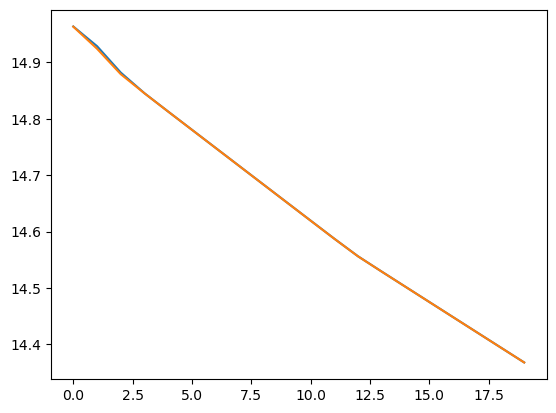

In [56]:
plt.plot(temp_1[:,0])
plt.plot(temp_2[:,0])
print(temp_1[:,0]-temp_2[:,0])